## SVM Model on Augmented Image Data

### Import Libraries

In [3]:
import os
import time
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.utils import resample
from PIL import Image
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, label_binarize
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


### Configuration

In [4]:
# Config
train_metadata_path = "train_augmented_metadata.csv"
train_image_folder = r"augmented_photos\train"
test_metadata_path = "test_metadata.csv"
test_image_folder = r"split_photos\test"
image_size = (128, 128)

### Load Dataset

In [5]:
# Helper function to load and flatten images
def load_flattened_images(image_folder, label_map):
    X, y = [], []
    for filename in os.listdir(image_folder):
        photo_id = os.path.splitext(filename)[0]
        if photo_id in label_map:
            path = os.path.join(image_folder, filename)
            img = Image.open(path).convert("RGB")
            X.append(np.array(img).flatten())
            y.append(label_map[photo_id])
    return np.array(X), np.array(y)

In [6]:
# Load train metadata and images
train_df = pd.read_csv(train_metadata_path)
train_label_map = dict(zip(train_df["photo_id"], train_df["label"]))
X_train, y_train = load_flattened_images(train_image_folder, train_label_map)

# Load test metadata and images
test_df = pd.read_csv(test_metadata_path)
test_label_map = dict(zip(test_df["photo_id"], test_df["label"]))
X_test, y_test = load_flattened_images(test_image_folder, test_label_map)

In [7]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### Dimensionality reduction - Principal Component Analysis (PCA)

In [8]:
# Reduce 49152 features to 3000
pca = PCA(n_components=300, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [9]:
X_train_pca.shape

(17192, 300)

Reduced the featues to be considered to 300 

### Model Training

In [10]:
# Train SVC with probability estimates
model = SVC(kernel="rbf", C=1.0, probability=True)

start_time = time.time()
model.fit(X_train_pca, y_train)
end_time = time.time()

training_time = end_time - start_time
print(f"Training complete. Training Time: {training_time:.2f} seconds")

Training complete. Training Time: 315.89 seconds


### Model Evaluation

In [11]:
# Define a function for evaluation with different metrics
def evaluate_model(X, y_true, dataset_name=""):
    
    # Predict
    y_pred = model.predict(X)

    # Accuracy 
    acc = accuracy_score(y_true, y_pred)
    print(f"{dataset_name} Accuracy: {acc * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    plt.show()


#### Train Set

Train Set Accuracy: 73.69%


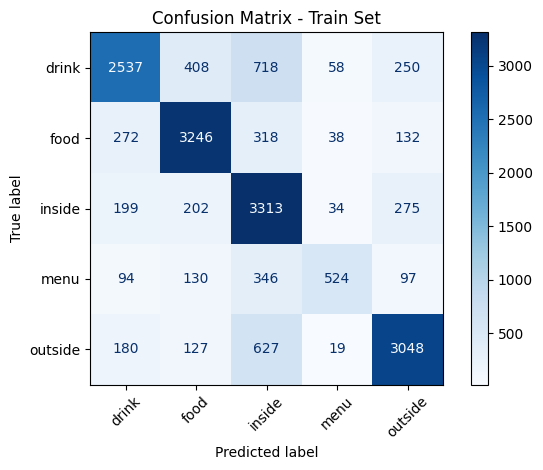

In [12]:
# Evaluate on train set
evaluate_model(X_train_pca, y_train, dataset_name="Train Set")

#### Test Set

Test Set Accuracy: 60.73%


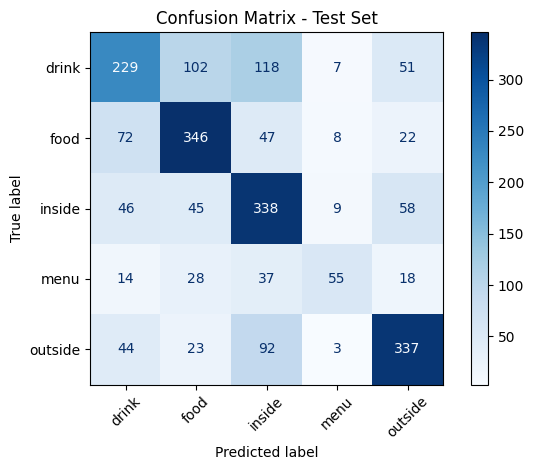

In [13]:
# Evaluate on test set
evaluate_model(X_test_pca, y_test, dataset_name="Test Set")

## Key Observations and Summary

### Overall Accuracy

Train Set	73.69%

Test Set	60.73%

### Observation 

The model performs significantly better on the training set than the test set, suggesting overfitting — the model has learned the training data too well and doesn't generalize as effectively to unseen data.

### Confusion Matrix Breakdown

##### Train set confusion matrix : 
Most accurate predictions: Inside and Food.

Common misclassifications:
Drink is often confused with Inside (718 cases).
Outside misclassified as Inside (627 cases).
Menu is moderately misclassified across all classes — it may be less distinct visually or in feature space.

##### Test Set Confusion Matrix : 
Performance drops significantly for:

Drink: more confusion with Food and Inside.

Menu: again, very scattered predictions (low precision/recall).

Inside and Food still retain relatively strong prediction performance.

### Key Insights
##### Strong classes: food, inside, outside (especially on train set).

##### Weak class: menu, due to consistently lower true positives and high misclassifications.

##### Class confusion: drink vs inside, outside vs inside — they may share similar visual characteristics, which PCA couldn't separate clearly.


#### Plot AUC and ROC 

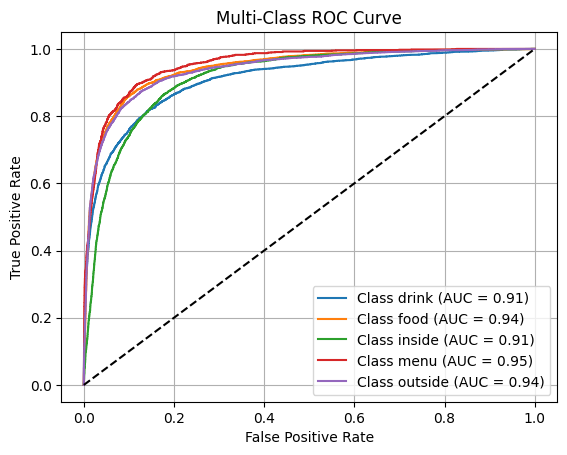

In [14]:
# Get class labels
classes = np.unique(y_train)

# Binarize the true labels
y_train_bin = label_binarize(y_train, classes=classes)

# Predict probabilities (for decision_function use: model.decision_function(X_train_pca))
y_score = model.predict_proba(X_train_pca)

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure()
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## Model Tuning 

#### Handling Class Imbalance

In [15]:
# Check class distribution
print("Class distribution:")
print(Counter(y_train))


Class distribution:
Counter({'inside': 4023, 'food': 4006, 'outside': 4001, 'drink': 3971, 'menu': 1191})


##### Computed class weights

In [16]:
# Get class labels
classes = np.unique(y_train)

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Convert to dict format required by SVC
class_weight_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weight_dict)


Class Weights: {'drink': 0.8658776126920171, 'food': 0.8583125312031952, 'inside': 0.8546855580412628, 'menu': 2.886985726280437, 'outside': 0.8593851537115721}


##### Train model with the class weights 

In [17]:
model = SVC(kernel="rbf", C=1.0, probability=True, class_weight=class_weight_dict)
model.fit(X_train_pca, y_train)

SVC(class_weight={'drink': 0.8658776126920171, 'food': 0.8583125312031952,
                  'inside': 0.8546855580412628, 'menu': 2.886985726280437,
                  'outside': 0.8593851537115721},
    probability=True)

In [18]:
# Define your class labels (should match training labels)
classes = np.unique(y_train)

# Binarize the true labels
y_true_bin = label_binarize(y_train, classes=classes)

# Predict probabilities
y_score = model.predict_proba(X_train_pca)

# Calculate FPR, TPR, AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

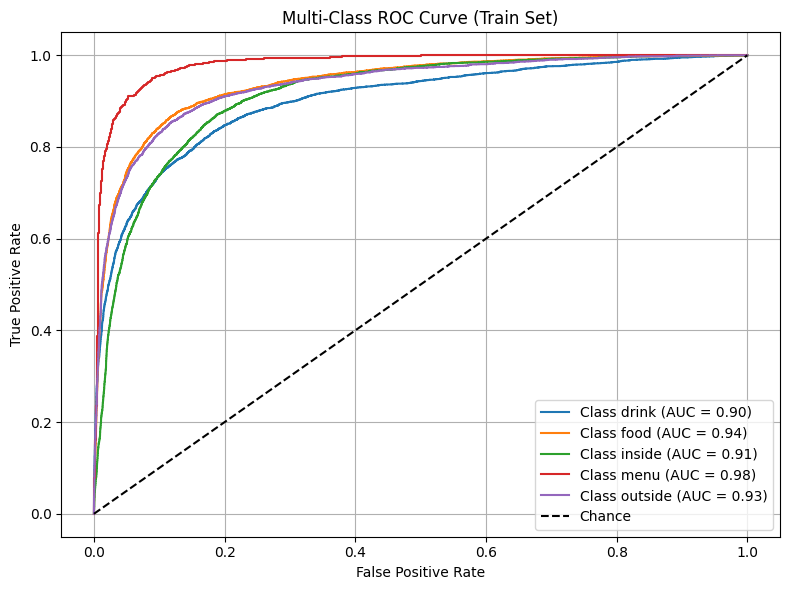

In [19]:
plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (Train Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


##### Model Evaluation 

Train Set Accuracy: 73.77%


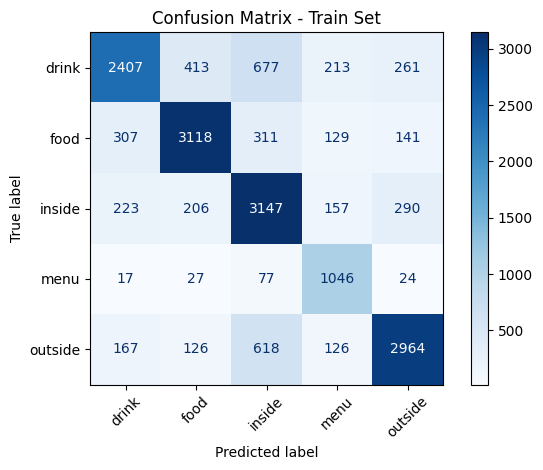

Test Set Accuracy: 60.49%


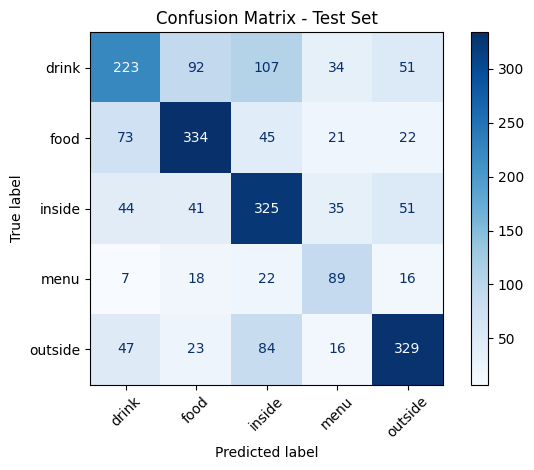

In [20]:
evaluate_model(X_train_pca, y_train, "Train Set")
evaluate_model(X_test_pca, y_test, "Test Set")


####  Grid Search Cross Validation

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid_search = GridSearchCV(SVC(probability=True, class_weight=class_weight_dict),
                           param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_pca, y_train)
model = grid_search.best_estimator_


Fitting 3 folds for each of 9 candidates, totalling 27 fits


In [22]:
model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [23]:
def evaluate_model(X, y_true, dataset_name=""):
    # Predict class labels and probabilities
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"{dataset_name} Accuracy: {acc * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=le.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    plt.show()

    # ROC AUC per class
    y_true_bin = label_binarize(y_true, classes=le.classes_)
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(len(le.classes_)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves
    plt.figure(figsize=(8, 6))
    for i in range(len(le.classes_)):
        plt.plot(fpr[i], tpr[i], label=f"Class {le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Train Set Accuracy: 73.77%


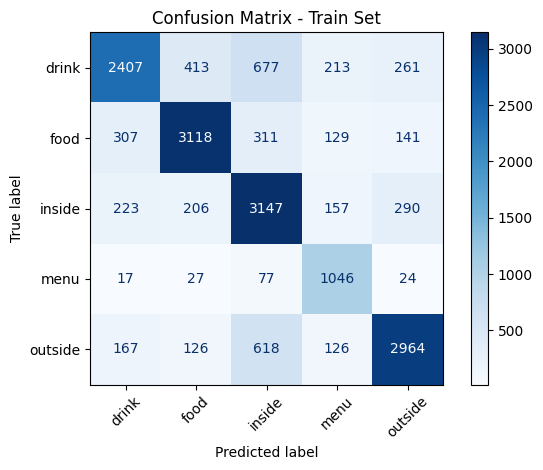

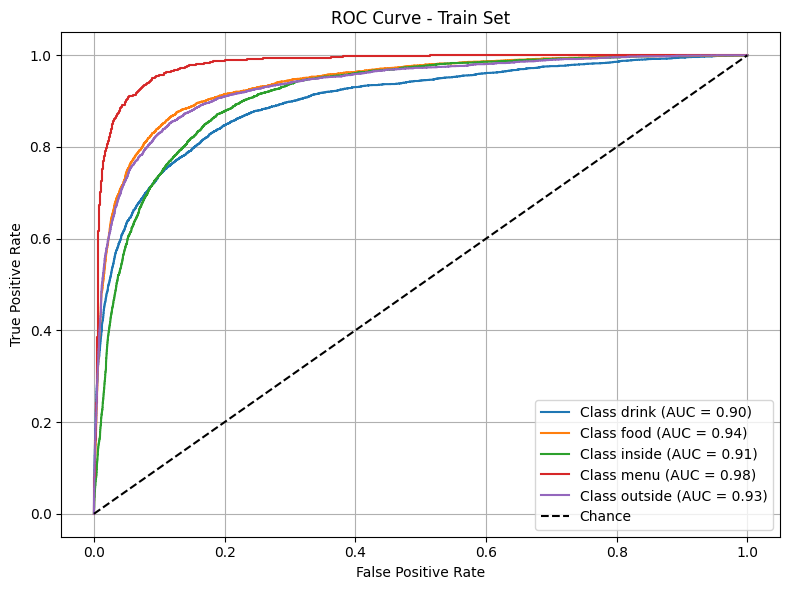

Test Set Accuracy: 60.49%


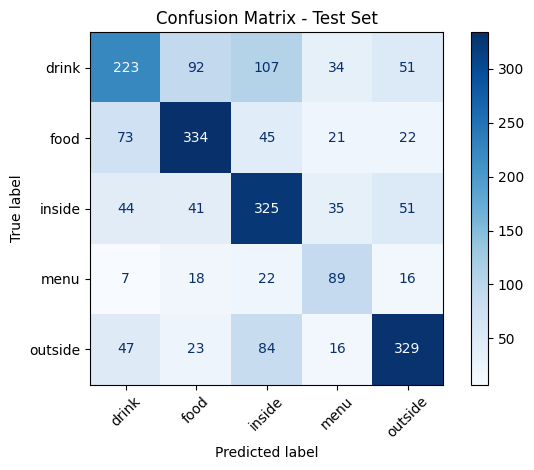

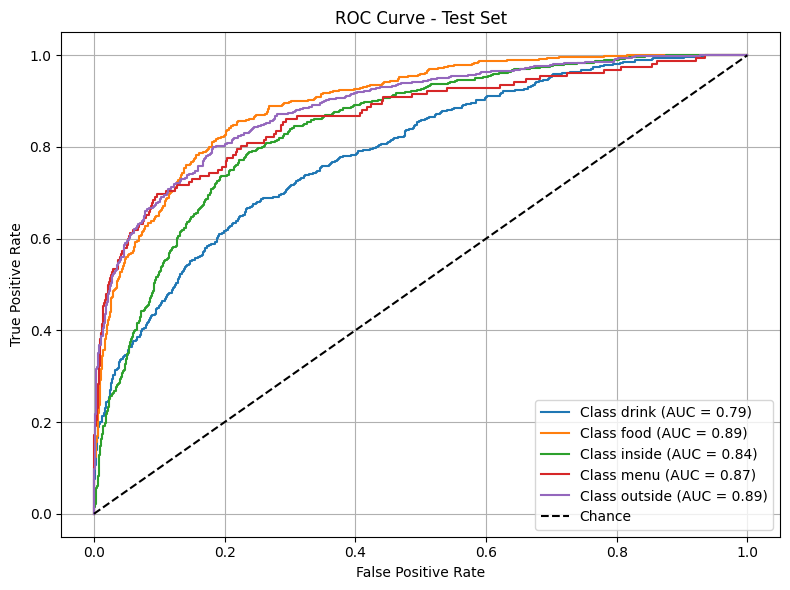

In [24]:
evaluate_model(X_train_pca, y_train, "Train Set")
evaluate_model(X_test_pca, y_test, "Test Set")

### Interpretability

In [25]:
!pip install shap


In [26]:
import shap
from sklearn.preprocessing import LabelEncoder

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Re-encode your labels if not already done
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_sampled_encoded = le.fit_transform(y_train)  # y_train_sampled = string labels

# Compute class weights using encoded labels
classes = np.unique(y_train_sampled_encoded)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_sampled_encoded)
class_weight_dict = dict(zip(classes, weights))

# Print to confirm
print("Class weights:", class_weight_dict)


Class weights: {0: 0.8658776126920171, 1: 0.8583125312031952, 2: 0.8546855580412628, 3: 2.886985726280437, 4: 0.8593851537115721}


In [27]:
from sklearn.svm import SVC

svm_advanced = SVC(kernel="rbf", C=1.0, gamma='scale', probability=True, class_weight=class_weight_dict)
svm_advanced.fit(X_train_pca, y_train_sampled_encoded)


SVC(class_weight={0: 0.8658776126920171, 1: 0.8583125312031952,
                  2: 0.8546855580412628, 3: 2.886985726280437,
                  4: 0.8593851537115721},
    probability=True)

In [28]:
!pip install lime

In [29]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Create the explainer using training data
explainer = LimeTabularExplainer(
    training_data=X_train_pca,
    feature_names=[f"PC{i}" for i in range(X_train_pca.shape[1])],
    class_names=np.unique(y_train),
    mode="classification"
)

# Pick a test instance to explain
i = 0  # You can change this index to test different samples
sample = X_test_pca[i]
true_label = y_test[i]

# Run LIME explanation
exp = explainer.explain_instance(
    data_row=sample,
    predict_fn=model.predict_proba,
    num_features=10  # Top 10 contributing features
)

# Show in notebook
exp.show_in_notebook(show_table=True)

# Optional: save as HTML
exp.save_to_file('lime_explanation_instance_0.html')

# Optional: print prediction vs actual
print("Predicted:", model.predict(sample.reshape(1, -1))[0])
print("Actual label:", true_label)


Predicted: outside
Actual label: drink
